# Task 1-2

In [48]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from keras.optimizers import Adam, SGD, RMSprop

from tqdm.keras import TqdmCallback

x_train shape:  (60000, 28, 28)
x_test shape:  (10000, 28, 28)


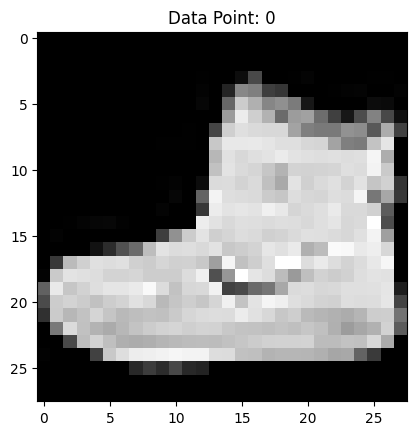

[9 0 0 ... 3 0 5]


In [38]:
# Load the dataset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Prepare input
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')
print("x_train shape: ", x_train.shape)
print("x_test shape: ", x_test.shape)

data_point_index = 0  # Choose the index of the data point you want to display

# Reshape the data point to a 28x28 image
image = x_train[data_point_index].reshape(28, 28)

# Display the image using matplotlib
plt.imshow(image, cmap='gray')  # Use 'gray' colormap for grayscale images
plt.title(f"Data Point: {data_point_index}")
plt.show()

# Normalize the pixel values to the range [0, 1]
x_train = x_train / 255.0
x_test = x_test / 255.0

Checking number of output classes

In [39]:
y_train

array([9, 0, 0, ..., 3, 0, 5], dtype=uint8)

## Single-Layer Neural Network

In [35]:
# define model
model_single_layer = Sequential()
model_single_layer.add(Flatten(input_shape=(28,28)))
model_single_layer.add(Dense(10, activation='softmax'))

# compile the model
model_single_layer.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# fit the model
model_single_layer.fit(x_train, y_train, epochs=20, batch_size=100, verbose=0, callbacks=[TqdmCallback(verbose=1)])

0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]

In [28]:
# Evaluate the single-layer model
test_loss_single, test_acc_single = model_single_layer.evaluate(x_test, y_test, verbose=2)
print(f"Single-Layer Model - Test Loss: {test_loss_single}, Test Accuracy: {test_acc_single}")

313/313 - 0s - 2ms/step - accuracy: 0.8428 - loss: 0.4453
Single-Layer Model - Test Loss: 0.4453372657299042, Test Accuracy: 0.8428000211715698


## Multi-Layer Perceptron (MLP)

In [45]:
# Multi-Layer Perceptron (MLP)
model_mlp = Sequential([
    Flatten(input_shape=(28, 28)),  # Flatten the 28x28 image to a 784-dimensional vector
    Dense(256, activation='relu'),  # First hidden layer with 256 units and ReLU activation
    Dense(256, activation='relu'),  # Second hidden layer with 128 units and ReLU activation
    Dense(10, activation='softmax')  # Output layer with 10 units (one for each class)
])

model_mlp.compile(optimizer=Adam(learning_rate=0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the MLP model
history_mlp = model_mlp.fit(x_train, y_train, epochs=10, batch_size=100, validation_data=(x_test, y_test), verbose=0, callbacks=[TqdmCallback(verbose=1)])

0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]

In [46]:
# Evaluate the MLP model
test_loss_mlp, test_acc_mlp = model_mlp.evaluate(x_test, y_test, verbose=2)
print(f"MLP Model - Test Loss: {test_loss_mlp}, Test Accuracy: {test_acc_mlp}")

313/313 - 1s - 3ms/step - accuracy: 0.8770 - loss: 0.3553
MLP Model - Test Loss: 0.3553107678890228, Test Accuracy: 0.8769999742507935
